# 随机森林

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/logo.png" width=150>

在本节课，我们将探索决策树，并且拓展它到随机森林。这种类型的模型，和我们之前见过的线性和逻辑回归不同，他们没有权重但是有很好的可解释性。




# 概述

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/dtree.jpg" width=350>

* **目标:**  给出一些数据，选择特征并且决定以什么样的方式分裂数据来做出预测。
* **优点:**
  * 决策树可以做成分类树和回归树。
  * 具有很强的可解释性.
  * 仅需很少的数据预处理。
* **缺点:**
  * 当训练数据少于分类类别的时候表现很差。
* **其他:** 一组决策树可以构成随机森林，预测结果也会由所有的决策树所决定。

# 训练

我们来看上方的决策树样例，它用来决策外面的天气是否可以在外玩耍。数据有三个特征(weather, humiditiy和wind) 和结果 (yes or no).

*步骤*: 
1.   基于每一个特征进行分割(例如. 根据三个特征来判断结果是yes还是no）
2.   计算每个特征分裂时候的损失。一些热门的算法比如使用Gini系数来计算的CART算法，还有使用熵和信息增益来计算的ID3。它们都基本上测量了预测值中的杂质或者无序。详细请见 [blog post](https://medium.com/deep-math-machine-learning-ai/chapter-4-decision-trees-algorithms-b93975f7a1f1) 一个详尽的信息增益计算步骤。

  * $ H(X) = \sum_{c \in C} -p(c) log_2p(c)$
  * where:
      * H(X): 数据集X的熵
      * C: 类别集合
      * p(c): 在c类别中和所有实例的占比
      
  对于一个二分类任务来说，如果所有的样例在一个类别下都是相同的，那么它的熵值为0，如果仅有一半是正确的，那么它的熵值则为1（也是最差的情况等同于瞎猜）。一旦我们决定了熵值，我们需要计算出信息增益(IG)(比如. 在我们把数据X基于特征F分裂后不确定的样本减少了多少)。
  
  * $ IG(F, X) = H(S) - \sum_{t\in T}p(t)H(t) $
  * where:
      * IG(F. X): 数据X基于特征F分裂后的信息增益
      * H(X): 数据集X的熵
      * T: 基于分裂F后的子集
      * p(t): 所有实例中t的实例数的比例
      * H(t): 子集t的熵
      
 **注意**: 对于回归问题，你可以用标准偏差（standard deviation）来取代信息增益。

3.   在所有的特征分裂后，信息增益最高的分裂将作为第一个特征的分裂(也就是决策树的根).
4.   基于第一次分裂后，重复上述的步骤在余下的所有特征中。最后，我们将分裂到叶子结点，在叶子结点中大部分样本将会来自同一类。

  

# 数据

我们来加载在第三节课中用到的titanic数据集

In [1]:
from argparse import Namespace
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import urllib

In [2]:
# 参数
args = Namespace(
    seed=42,
    data_file="titanic.csv",
    train_size=0.75,
    test_size=0.25,
    num_epochs=100,
    max_depth=4,
    min_samples_leaf=5,
    n_estimators=10, # 随机森林中包含的决策树个数
)

# 设置随即种子来保证实验结果的可重复性。
np.random.seed(args.seed)

In [3]:
'''
# 从GitHub上加载数据到notebook本地驱动
url = "https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/data/titanic.csv"
response = urllib.request.urlopen(url)
html = response.read()
with open(args.data_file, 'wb') as f:
    f.write(html)
'''

'\n# 从GitHub上加载数据到notebook本地驱动\nurl = "https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/data/titanic.csv"\nresponse = urllib.request.urlopen(url)\nhtml = response.read()\nwith open(args.data_file, \'wb\') as f:\n    f.write(html)\n'

In [4]:
# 把CSV文件内容读到DataFrame中
# header=0  用文件的第 1 行作为列名（默认值，可省略）
df = pd.read_csv(args.data_file, header=0)
df.head()

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0


# Scikit-learn实现

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
# 预处理
def preprocess(df):
  
    # 删除掉含有空值的行
    df = df.dropna()

    # 删除基于文本的特征 (我们以后的课程将会学习怎么使用它们)
    features_to_drop = ["name", "cabin", "ticket"]
    df = df.drop(features_to_drop, axis=1)

    # pclass, sex, 和 embarked 是类别变量
    # 我们将把字符串转化成浮点数，不再是逻辑回归中的编码变量
    df['sex'] = df['sex'].map( {'female': 0, 'male': 1} ).astype(int)
    df["embarked"] = df['embarked'].map( {'S':0, 'C':1, 'Q':2} ).astype(int)

    return df

In [7]:
# 数据预处理
df = preprocess(df)
df.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,0,29.0000,0,0,211.3375,0,1
1,1,1,0.9167,1,2,151.5500,0,1
2,1,0,2.0000,1,2,151.5500,0,0
3,1,1,30.0000,1,2,151.5500,0,0
4,1,0,25.0000,1,2,151.5500,0,0


In [8]:
# 划分数据到训练集和测试集
mask = np.random.rand(len(df)) < args.train_size
train_df = df[mask]
test_df = df[~mask]
print ("Train size: {0}, test size: {1}".format(len(train_df), len(test_df)))

Train size: 203, test size: 67


In [9]:
# 分离 X 和 y
X_train = train_df.drop(["survived"], axis=1)
y_train = train_df["survived"]
X_test = test_df.drop(["survived"], axis=1)
y_test = test_df["survived"]

**注意**: 你可以随意改动 max_depth 和 min_samples 来观察决策树表现好坏的变化。
我们怎么知道什么时候可以停止分裂？如果我们有一个很多特征的数据集，我们的决策树也会非常大。如果我们一直去分裂，我们终究会导致过拟合。所以这里有一些处理办法可以参考：

*  设置在叶子节点中的最少样本个数。
*  设置一个最大的深度(也就是从树根到叶子节点的最大距离)。
*  通过删除几乎没有信息增益的特征对决策树进行剪枝。

In [10]:
# 初始化模型
dtree = DecisionTreeClassifier(criterion="entropy", #分裂规则
                               random_state=args.seed, 
                               max_depth=args.max_depth, 
                               min_samples_leaf=args.min_samples_leaf # 叶子里面的最小样本数
                              )

In [11]:
# 训练
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [12]:
# 预测
pred_train = dtree.predict(X_train)
pred_test = dtree.predict(X_test)

# 评估

In [13]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

In [14]:
# 正确率
train_acc = accuracy_score(y_train, pred_train)
test_acc = accuracy_score(y_test, pred_test)
print ("train acc: {0:.2f}, test acc: {1:.2f}".format(train_acc, test_acc))

train acc: 0.79, test acc: 0.82


In [15]:
# 计算其他的模型评估指标
# binary 二分类专用参数（只计算【正例】的指标，比如生还 = 1）
# 返回的最后一个是样本量，此处没用，省略
precision, recall, F1, _ = precision_recall_fscore_support(y_test, pred_test, average="binary")
print ("precision: {0:.2f}. recall: {1:.2f}, F1: {2:.2f}".format(precision, recall, F1))

precision: 0.97. recall: 0.78, F1: 0.86


# 可解释性

In [16]:
# 安装必要的包
# 安装graphviz，是一个库，手动安装，配置环境变量
# !pip install pydotplus
import os
# 临时给python添加路径，用来识别graphviz
os.environ["PATH"] += os.pathsep + r"D:\Miniconda3\Graphviz\bin"

In [17]:
from io import StringIO
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus

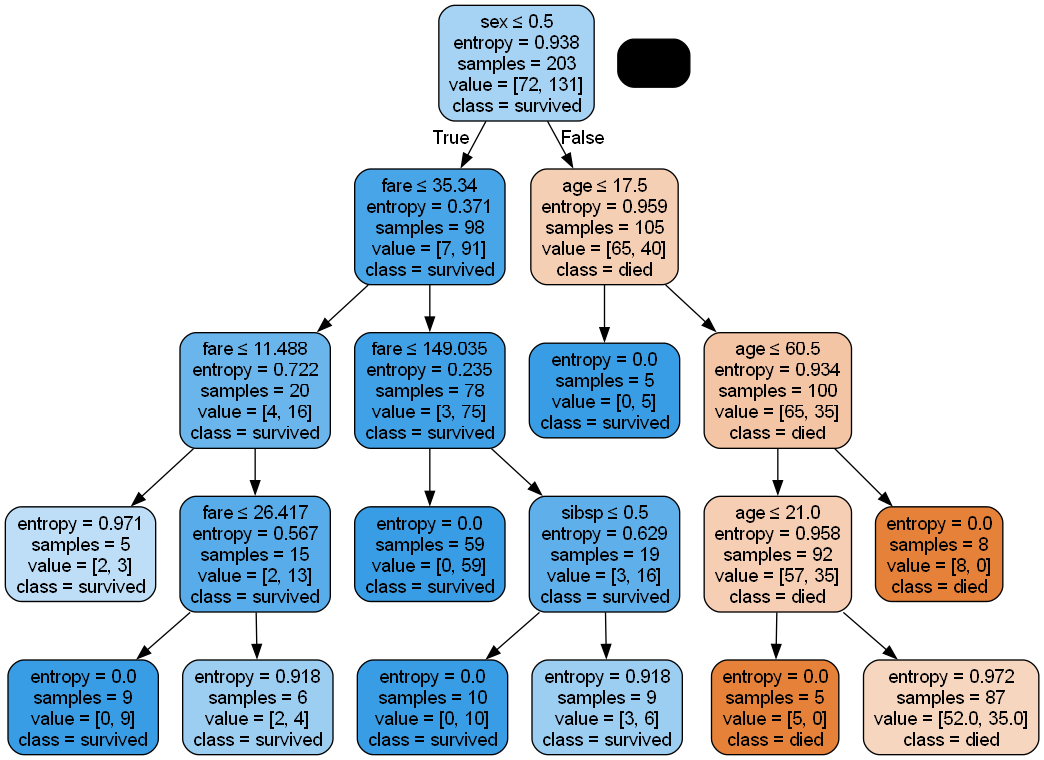

In [18]:
# 1. 创建一个内存缓冲区，用来临时存储绘图数据（不生成本地文件）
dot_data = StringIO()

# 2. 核心函数：将决策树模型转换为 Graphviz 可识别的绘图格式
export_graphviz(
    dtree,                      # 你训练好的决策树模型
    out_file=dot_data,          # 绘图数据输出到内存缓冲区
    feature_names=list(train_df.drop(['survived'], axis=1)),  # 特征名称（所有输入模型的列）
    class_names = ['died', 'survived'],  # 分类标签：0=死亡，1=生还
    rounded = True,             # 节点设置为圆角，更美观
    filled= True,               # 给节点填充颜色，区分分类
    special_characters=True     # 支持特殊字符，避免中文/符号乱码
)

# 3. 读取内存中的绘图数据，生成 Graphviz 图形对象
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  

# 4. 在 Jupyter 笔记本中直接显示图片（指定宽高）
Image(graph.create_png(), width=500, height=300)

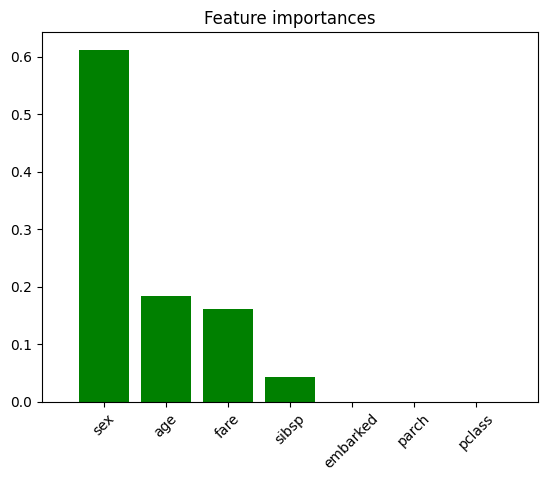

sex - 0.612
age - 0.184
fare - 0.161
sibsp - 0.042
embarked - 0.000
parch - 0.000
pclass - 0.000


In [37]:
# 1. 获取所有特征的名称（从测试集X_test的列名中提取）
features = list(X_test.columns)

# 2. 提取决策树模型计算出的【特征重要性分数】
# 分数越高 → 该特征对预测结果的影响越大
importances = dtree.feature_importances_

# 3. 对特征重要性【从大到小排序】，返回排序后的索引
# np.argsort(importances) → 从小到大排序
# [::-1] → 反转，变成从大到小
indices = np.argsort(importances)[::-1]

# 4. 统计总共有多少个特征
num_features = len(importances)

# ------------------- 绘制特征重要性柱状图 -------------------
plt.figure()                # 创建画布
plt.title("Feature importances")  # 图表标题
# 绘制柱状图：x轴=特征序号，y轴=排序后的重要性分数，绿色，居中对齐
plt.bar(range(num_features), importances[indices], color="g", align="center")
# x轴标签：替换为特征名称，旋转45度防止文字重叠
plt.xticks(range(num_features), [features[i] for i in indices], rotation=45)
plt.xlim([-1, num_features]) # 设置x轴范围，让图表更美观
plt.show()                  # 显示图片

# ------------------- 打印特征重要性数值 -------------------
# 循环遍历排序后的索引，打印【特征名 + 重要性分数（保留3位小数）】
for i in indices:
    print ("{0} - {1:.3f}".format(features[i], importances[i]))

# 随机森林

随机森林由一组，或者说一个集成的决策树在一起构建。它的意图是，与单个决策树相比，一组不同的树将产生更准确的预测。 但是如果我们在相同的数据下用相同的分裂条件比如说信息增益，那么怎么保证每棵树又是不同的呢？这里的解决方法是随机森林中的不同决策树由不同的数据子集组成，甚至不同的特征阈值。

<img src="https://raw.githubusercontent.com/LisonEvf/practicalAI-cn/master/images/forest.png" width=600>

# Scikit-learn 实现

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
# 初始化随机森林
forest = RandomForestClassifier(
    n_estimators=args.n_estimators, # 决策树的个数
    criterion="entropy", 
    max_depth=args.max_depth, 
    min_samples_leaf=args.min_samples_leaf)

In [22]:
# 训练
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [23]:
# 预测
pred_train = forest.predict(X_train)
pred_test = forest.predict(X_test)

In [24]:
# 正确率
train_acc = accuracy_score(y_train, pred_train)
test_acc = accuracy_score(y_test, pred_test)
print ("train acc: {0:.2f}, test acc: {1:.2f}".format(train_acc, test_acc))

# 计算其他评估指标 
precision, recall, F1, _ = precision_recall_fscore_support(y_test, pred_test, average="binary")
print ("precision: {0:.2f}. recall: {1:.2f}, F1: {2:.2f}".format(precision, recall, F1))

train acc: 0.78, test acc: 0.82
precision: 0.91. recall: 0.84, F1: 0.87


# 可解释性

检查随机森林正确性并获得特征重要性非常容易。

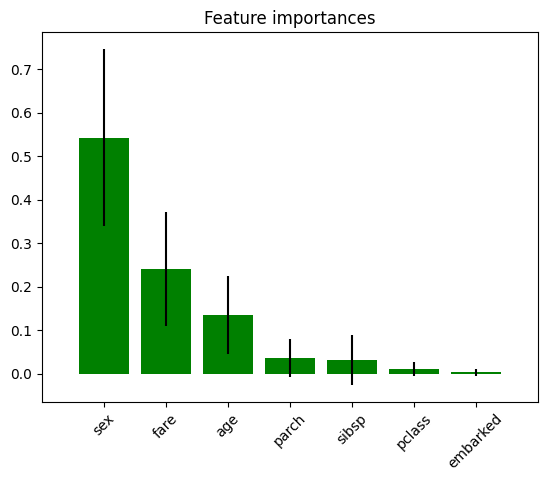

sex - 0.542
fare - 0.241
age - 0.135
parch - 0.036
sibsp - 0.032
pclass - 0.011
embarked - 0.003


In [25]:
# 1. 获取测试集所有特征的名称
features = list(X_test.columns)

# 2. 获取随机森林的【平均特征重要性】（所有树投票后的最终结果）
importances = forest.feature_importances_

# 🌟3. 计算特征重要性的【标准差】（衡量稳定性：随机森林多棵树的差异）
# forest.estimators_ = 森林里所有的决策树列表
# [tree.feature_importances_ for tree in ...] = 提取每棵树的特征重要性
# np.std(..., axis=0) = 按列计算标准差（每一个特征的波动大小）
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

# 4. 对特征重要性【从大到小排序】，返回索引
indices = np.argsort(importances)[::-1]

# 5. 统计总特征数量
num_features = len(importances)

# ------------------- 绘图 -------------------
plt.figure()           # 创建画布
plt.title("Feature importances")  # 标题

# 6. 绘制柱状图 + 🌟误差棒
plt.bar(
    range(num_features),   # X轴：特征位置
    importances[indices],  # Y轴：重要性分数（柱子高度）
    yerr=std[indices],     # 🌟 误差棒（竖线）：标准差，展示重要性稳定性
    color="g",            # 颜色：绿色
    align="center"        # 居中对齐
)

# 7. X轴标签：替换为特征名，旋转45度
plt.xticks(range(num_features), [features[i] for i in indices], rotation=45)

# 8. X轴范围：左右留白，更美观
plt.xlim([-1, num_features])

# 9. 显示图表
plt.show()

# 10. 打印排序后的特征名 + 重要性分数（保留3位小数）
for i in indices:
    print ("{0} - {1:.3f}".format(features[i], importances[i]))

# 网格搜索

在我们的随机森林中，我们有许多不同的超参数(criterion, max_depth, 等等)甚至在以后的课程中我们会见到很多的模型有更多的超参数。我们怎么知道应该选择什么样的值？我们必须根据它们在验证集上产生的性能来调整它们。Scikit learn提供了详尽的网格搜索功能，以便我们可以调整我们的超参数。

In [26]:
from sklearn.model_selection import GridSearchCV

In [27]:
# 创建网格的参数 
param_grid = {
    'bootstrap': [True], #是否采用有放回抽样
    'max_depth': [10, 20, 50],
    'max_features': [len(features)], # 每棵树分裂时，最多使用多少个特征
    'min_samples_leaf': [3, 4, 5],
    'min_samples_split': [4, 8], # 内部节点再分裂的最小样本数
    'n_estimators': [5, 10, 50] # of trees
}

In [28]:
# 初始化随机森林
forest = RandomForestClassifier()

In [29]:
# 实例化网格搜索
grid_search = GridSearchCV(estimator=forest, 
                           param_grid=param_grid, 
                           cv=3,  # 3 折交叉验证
                           n_jobs=-1,  # 调用电脑所有 CPU 核心并行计算
                           verbose=1 # 控制训练时的打印日志
                          )

In [30]:
# 网格搜索拟合数据
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 54 candidates, totalling 162 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [10, 20, ...], 'max_features': [7], 'min_samples_leaf': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is display

In [31]:
# 查看最佳参数组合
grid_search.best_params_

{'bootstrap': True,
 'max_depth': 10,
 'max_features': 7,
 'min_samples_leaf': 4,
 'min_samples_split': 8,
 'n_estimators': 5}

In [32]:
# 使用最佳参数训练
best_forest = grid_search.best_estimator_ # 它会自动把遍历后效果最好的那组参数封装成一个完整的随机森林模型
best_forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",5
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",8
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",7
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, 

In [33]:
# 预测
pred_train = best_forest.predict(X_train)
pred_test = best_forest.predict(X_test)

In [34]:
# 正确率
train_acc = accuracy_score(y_train, pred_train)
test_acc = accuracy_score(y_test, pred_test)
print ("train acc: {0:.2f}, test acc: {1:.2f}".format(train_acc, test_acc))

# 计算其他评价指标
precision, recall, F1, _ = precision_recall_fscore_support(y_test, pred_test, average="binary")
print ("precision: {0:.2f}. recall: {1:.2f}, F1: {2:.2f}".format(precision, recall, F1))

train acc: 0.85, test acc: 0.73
precision: 0.88. recall: 0.73, F1: 0.80


# TODO

- regression example
- gini vs. entropy